---
title: "Chebyshev polynomials"
subtitle: "Lecture 7: Chapter 3: Polynomial interpolation"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

## Previously.....

- Lagrange interpolation problem (find $p\in \mathcal P_n$ such that $p(x_j) = f(x_j) =: f_j$ for all $x_j \in X = \{x_0 < \cdots < x_n\}$)
- Theorem: there exists unique polynomial interpolation $I_Xf \in \mathcal P_n$ solving the Lagrange interpolation problem, 
- Theorem: "Taylor-like" error estimate involving the *node polynomial* $\ell_X(x) := (x-x_0)(x-x_1)\cdots (x- x_n)$: there exists $\xi \in [a,b]$ such that 

\begin{align}
    f(x) - I_Xf(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!} \ell_X(x),
\end{align}

- Runge phenomena; interpolation in equispaced nodes diverged for $\frac{1}{1 + 25 x^2}$,
- Polynomial interpolation in Chebyshev nodes converged exponentially, 
- $|\ell_X(x)| \leq \frac{e}{2\sqrt{n}} \left( \frac2e \right)^n$ for equispaced nodes, 
- $|\ell_X(x)| \leq 2^{1-n}$ for Chebyshev nodes. 

::: {.box}

**Exercise.** @exr-poly-interpolation-2

:::

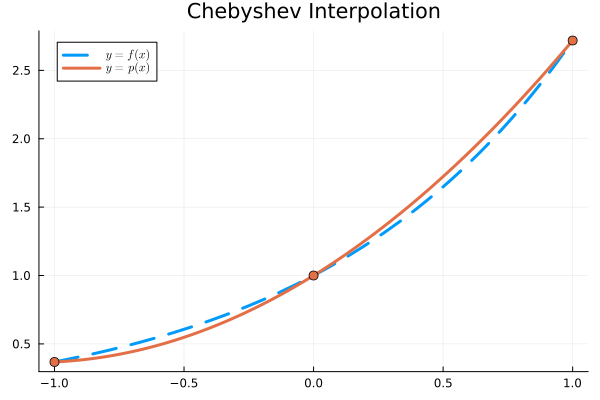

In [1]:
using Plots, LaTeXStrings, Polynomials

function f₁( x )
    return x + rand()
end

function f₂( x )
    return 1/( 1 + exp( x ) );
end

function f₃( x, α = 25 )
    return 1/( 1 + α*x^2 );
end

f₄ = t -> max(0, @. 1-abs(t) )

x = [-1,0,1]
y = @. exp( x )

p = fit(ChebyshevT, x, y)

plt1 = plot(x-> exp(x), -1, 1, label=L"y = f(x)", lw = 3, linestyle = :dash, title = "Chebyshev Interpolation")
plot!(plt1, p, -1, 1, label=L"y = p(x)", lw = 3 )
scatter!(plt1, [x], [y], primary = false, markersize = 5)

## How to choose $X$ to minimise $\| \ell_X \|_{L^\infty([-1,1])}$?

In this section, we will write $\| f \|_{L^\infty} := \max\limits_{x \in [-1,1]} |f(x)|$. 

Recall that 

\begin{align}
    \left\| f - I_Xf \right\|_{L^\infty} \leq \frac{\|f^{(n+1)}\|_{L^\infty}}{(n+1)!} \|\ell_X\|_{L^\infty}  
\end{align}

so it is natural to want to minimise 

\begin{align}
    \|\ell_X\|_{L^\infty} = \max_{x \in [-1,1]} |(x-x_0)(x-x_1)\dots(x-x_n)|
\end{align}

over all choices of $X = \{x_0,\dots,x_n\}$. Equivalently, we are minimising $\| p \|_{L^\infty}$ over all *monic* polynomials $p$ of degree $n+1$: that is, over all $p$ such that $p(x) = x^{n+1} + q(x)$ with $q\in \mathcal P_n$. We will show that scaled Chebyshev polynomials (of the first kind) solve this (so-called *Chebyshev*) problem.

## A Very Brief Introduction to Chebyshev Polynomials

::: {#def-chebyshev}

For $x \in [-1,1]$ there exists $\theta \in [0,\pi]$ such that $x = \cos\theta$. We can therefore define $T_n$ on $[-1,1]$ by the condition that

\begin{align}
T_n( \cos \theta ) = \cos n\theta.
\end{align}

for $n = 0,1,2,...$. 

:::

We will show that $T_n$ is a polynomial of degree $n$. We define $X_{\mathrm{I}}$ to be the set of $n+1$ zeros of $T_{n+1}$ and $X_{\mathrm{II}}$ to be the set of $n+1$ extreme points of $T_n$. We will show that 

\begin{align}
    X_{\mathrm I} &= \Big\{ \cos \frac{(2j+1)\pi}{2(n+1)} \Big\}_{j=0}^{n} \nonumber\\
    X_{\mathrm{II}} &= \big\{ \cos\tfrac{j\pi}{n} \big\}_{j=0}^n
\end{align}

$X_{\mathrm{I}}$ and $X_{\mathrm{II}}$ are the *Chebyshev nodes of the first and second kind*, respectively.

::: {#exr-Chebyshev-1}

Show that $T_0(x) = 1$ and $T_1(x) = x$.

:::

::: {#exr-Chebyshev-2}

Use $\cos(x+y) = \cos x \cos y - \sin x \sin y$ to show that 

* $T_{n+1}(x) = 2x T_{n}(x) - T_{n-1}(x)$ for $n =1,2,\dots$,
* Hence show that $T_n$ is a polynomial of degree $n$,
* Show that the coefficent of $x^n$ in $T_n$ is $2^{n-1}$ for $n \geq 1$.

:::

::: {#exr-Chebyshev-3}

Show that 

* $\|T_n\|_{L^\infty([-1,1])} = 1$,
* $T_{n}\big( \cos\tfrac{j\pi}{n} \big) = (-1)^j$ for $j = 0,\dots,n$ (extreme points; Chebyshev nodes of the second kind),
* $T_{n+1} = 0$ on $\big\{ \cos \frac{(2j+1)\pi}{2(n+1)} \big\}_{j=0}^{n}$ (zeros; Chebyshev nodes of the first kind).

:::

***Proof.*** Firstly, $T_0(\cos\theta) =\cos 0 = 1$ and so $T_0 = 1$. Moreover, $T_{1}(\cos \theta) = \cos\theta$ and so $T_1 = x$. 

Using the fact that $\cos(x+y) = \cos x \cos y - \sin x \sin y$ (which follows from e.g. $e^{i(x+y)} = e^{ix} e^{iy}$), we find that 

\begin{align}
    T_{n\pm1}(\cos\theta) &= \cos( n\theta \pm \theta) \nonumber\\
    %
    &= \cos \theta \cos n\theta  \mp  \sin\theta \sin n\theta.
\end{align}

The sum of these equations is therefore $T_{n+1}(\cos\theta) + T_{n-1}(\cos\theta) = 2 \cos \theta \cos n\theta = 2 \cos(\theta) T_n(\cos\theta)$ and thus the recursion relation follows.

One can therefore show inductively that $T_n$ is a polynomial of degree $n$. Using the recursion, the coeficient of $x^{n+1}$ in $T_{n+1}$ is $2$ times the coefficient of $x^n$ in $T_{n}$. You can therefore argue inductively that the coeficient of $x^n$ in $T_{n}$ is $2^{n-1}$.

We have $|T_n(\cos\theta)| = |\cos n\theta| \leq 1$ and this maximum is achieved when $n\theta = j\pi$ for some $j \in \mathbb Z$. Restricting this to $\theta = \frac{j\pi}{n} \in [0,\pi]$ gives $j = 0,\dots,n$. At these values, we have $T_n( \cos\tfrac{j\pi}{n} ) = \cos j\pi = (-1)^j$.

$T_{n+1}$ is a polynomial of degree $n+1$ and thus has at most $n+1$ zeros in the interval $[-1,1]$. We have $T_{n+1}(\cos\theta) = \cos (n+1)\theta = 0$ when $(n+1)\theta = \frac{\pi}{2} + j \pi$ for $j \in \mathbb Z$ such that $\theta = \frac{ (2j+1) \pi }{ 2(n+1) } \in [0,\pi]$. That is, for $j = 0,\dots,n$. $\square$

Here, we plot the first $5$ Chebyshev polynomials on $[-1,1]$ together with $(x, T_n(x))$ for $x \in X_{\mathrm{II}}$ with $n=5$

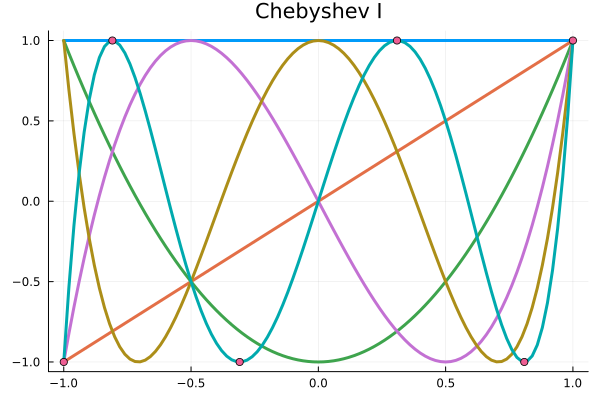

In [2]:
plot(ChebyshevT([1.]), -1, 1, title="Chebyshev I", legend = false, lw = 3)
plot!(ChebyshevT([0, 1]), -1, 1, title="Chebyshev I", legend = false, lw = 3)
plot!(ChebyshevT([0,0,1.]), -1, 1, title="Chebyshev I", legend = false, lw = 3)
plot!(ChebyshevT([0,0,0,1.]), -1, 1, title="Chebyshev I", legend = false, lw = 3)
plot!(ChebyshevT([0,0,0,0,1.]), -1, 1, title="Chebyshev I", legend = false, lw = 3)

p = ChebyshevT([0,0,0,0,0,1.])
plot!(p, -1, 1, title="Chebyshev I", legend = false, lw = 3)

scatter!( @. cos( pi*(0:5)/5 ), @. p( cos( pi* (0:5)/5 ) ) )

We define the *monic* (with leading coefficient equal to $1$) Chebyshev polynomials as $t_0(x) = 1$ and $t_n(x) := 2^{1-n} T_n(x)$ for $n \geq 1$. We are ready for the main result of this lecture:

::: {#thm-l07-1}

The monic Chebyshev polynomials solve the Chebyshev problem (on $[-1,1]$). That is, 

\begin{align}
    \|t_{n+1} \|_{L^\infty([-1,1])} \leq \min_{p = x^{n+1} + q : \,\, q \in \mathcal P_n  } \big\| p \big\|_{L^\infty([-1,1])}.
\end{align}

:::

***Proof.*** Here, we just write $\|\,\cdot\,\|_{L^\infty}$ for $\|\,\cdot\,\|_{L^\infty([-1,1])}$.

Suppose that $p$ minimises the right hand side of (1). Then, because $t_{n+1}$ is a monic polynomial of degree $n+1$, we must have 

\begin{align*}
    \big\|p \big\|_{L^\infty} \leq \| t_{n+1} \|_{L^\infty} = 2^{1-(n+1)} \| T_{n+1} \|_{L^\infty} = 2^{-n}
\end{align*}

Define $r(x) = t_{n+1}(x) - p(x)$ and note that 

\begin{align}
    r( z_j ) = (-1)^j 2^{-n} - p( z_j ), \qquad \text{for } z_j := \cos \frac{j\pi}{n+1}
\end{align}

and $j = 0,1,\dots,n+1$ (here, we have used the fact that $z_j$ are the extreme values of $T_{n+1}$ for $j=0,\dots,n+1$). 

Therefore, since $|p(x)| \leq 2^{-n}$ for all $x \in [-1,1]$, we have

\begin{align}
    r( z_j ) &= 2^{-n} - p( z_j ) \geq 0 \qquad &\text{for even } j \\
    r( z_j ) &= (-1) 2^{-n} - p( z_j ) \leq 0 \qquad &\text{for odd } j.
\end{align}

By the change of sign theorem, there exists $x_1,\dots,x_{n+1}$ such that $z_j \leq x_{j+1} \leq z_{j+1}$ and $r(x_j) = 0$. As a result, $r$ is a polynomial of degree at most $n$ with $n+1$ zeros and thus $r = 0$ and $p = t_{n+1}$. $\square$


We have therefore shown that, choosing $X =X_{\mathrm{I}}=  \{ \text{zeros of }t_{n+1} \}$ minimises the node polynomial in the following sense

\begin{align}
    \min_{ y_0 < \dots < y_n } \| \ell_{Y} \|_{L^\infty([-1,1])} \geq \| \ell_X \|_{L^\infty([-1,1])} = 2^{-n}
\end{align} 

It turns out that $\ell_{X_{\mathrm{II}}}(x) = 2^{-n} \big( T_{n+1}(x) - T_{n-1}(x) \big)$ and so $\|\ell_{X_{\mathrm{II}}}\|_{L^\infty([-1,1])} \leq 2^{1-n}$ (here, we used $|T_{n}|\leq 1$) and so, in practice, one expects the same approximation rates when using $X = X_{\mathrm{II}} = \{\text{extreme points of } T_n \}$.  

## Next time.... 

- Barycentric formula for Chebyshev interpolation
- Newton form & divided differences

:::{.callout-tip}
# TO-DO

* Wednesday morning: Quiz 2
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

:::

## Extra exercises


::: {#exr-l07-cheb-small}

Recall that $T_{n+1}(x) = 2x T_n(x) - T_{n-1}(x)$ for $n=1,2,...$.

1. Use the recursion to write down $T_2$, $T_3$ and $T_4$ in the monomial basis.
2. Write down the Chebyshev nodes of the first kind $X_{\mathrm I}$ for $n = 2$ (i.e. the zeros of $T_3$) and check directly that $\ell_{X_{\mathrm I}}(x) = t_3(x) = x^3 - \tfrac34 x$.
3. Find $\| \ell_{X_{\mathrm I}} \|_{L^\infty([-1,1])}$ for $n=2$ by calculus, and compare with the equispaced nodes $\{-1, 0, 1\}$.

:::

::: {#exr-l07-XII}

In the notes, we claimed that $\ell_{X_{\mathrm{II}}}(x) = 2^{-n} \big( T_{n+1}(x) - T_{n-1}(x) \big)$ for $n \geq 1$. Since $\|T_n\|_{L^\infty} = 1$, this gives $\| \ell_{X_{\rm II}} \|_{L^\infty} \leq 2^{1-n}$.

Prove the claim as follows:

1. Show that $T_{n+1}(\cos\theta) - T_{n-1}(\cos\theta) = -2 \sin\theta \sin n\theta$.
2. Deduce that $T_{n+1} - T_{n-1}$ vanishes on $X_{\mathrm{II}} = \big\{ \cos\frac{j\pi}{n} \big\}_{j=0}^n$.
3. Show that $2^{-n} \big( T_{n+1} - T_{n-1} \big)$ is monic of degree $n+1$, and conclude.

:::

::: {#exr-l07-interval}

Suppose we want to interpolate on a general interval $[a,b]$ rather than $[-1,1]$.

1. Let $\phi(t) = \frac{a+b}{2} + \frac{b-a}{2} t$, so that $\phi$ maps $[-1,1]$ onto $[a,b]$. If $Y = \{y_0,\dots,y_n\} \subset [-1,1]$ and $X = \phi(Y) = \{\phi(y_0), \dots, \phi(y_n)\}$, show that
   $$
       \ell_X\big(\phi(t)\big) = \left( \frac{b-a}{2} \right)^{n+1} \ell_Y(t).
   $$
2. Deduce that, if $X$ is the image of $X_{\mathrm I}$ under $\phi$, then $\max_{x \in [a,b]} |\ell_X(x)| = 2 \left( \frac{b-a}{4} \right)^{n+1}$.
3. Let $f(x) = \sin x$ on $[0, \pi]$, interpolated at the image of $X_{\mathrm I}$. Write down an error bound and find the smallest $n$ that guarantees $\max_{x\in[0,\pi]} |f(x) - I_Xf(x)| \leq 10^{-6}$.

:::